In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../Datasets/dataset.csv")

## Discrete and continuous histograms

array([[<Axes: title={'center': 'floor'}>,
        <Axes: title={'center': 'max_floor'}>],
       [<Axes: title={'center': 'elevator'}>, <Axes: >]], dtype=object)

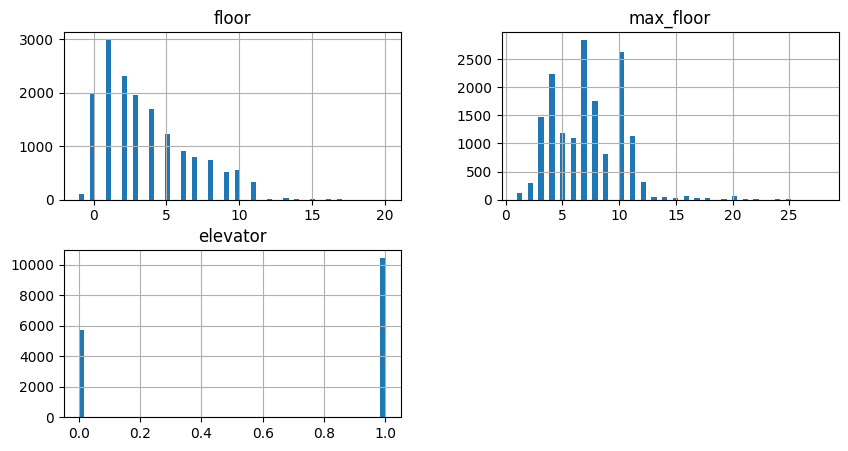

In [4]:
df.hist(figsize=(10,5),column=["floor","max_floor","elevator"],bins=(57))

array([[<Axes: title={'center': 'surface_m2'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'year_built'}>],
       [<Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'metro_proximity'}>],
       [<Axes: title={'center': 'stb_proximity'}>, <Axes: >, <Axes: >]],
      dtype=object)

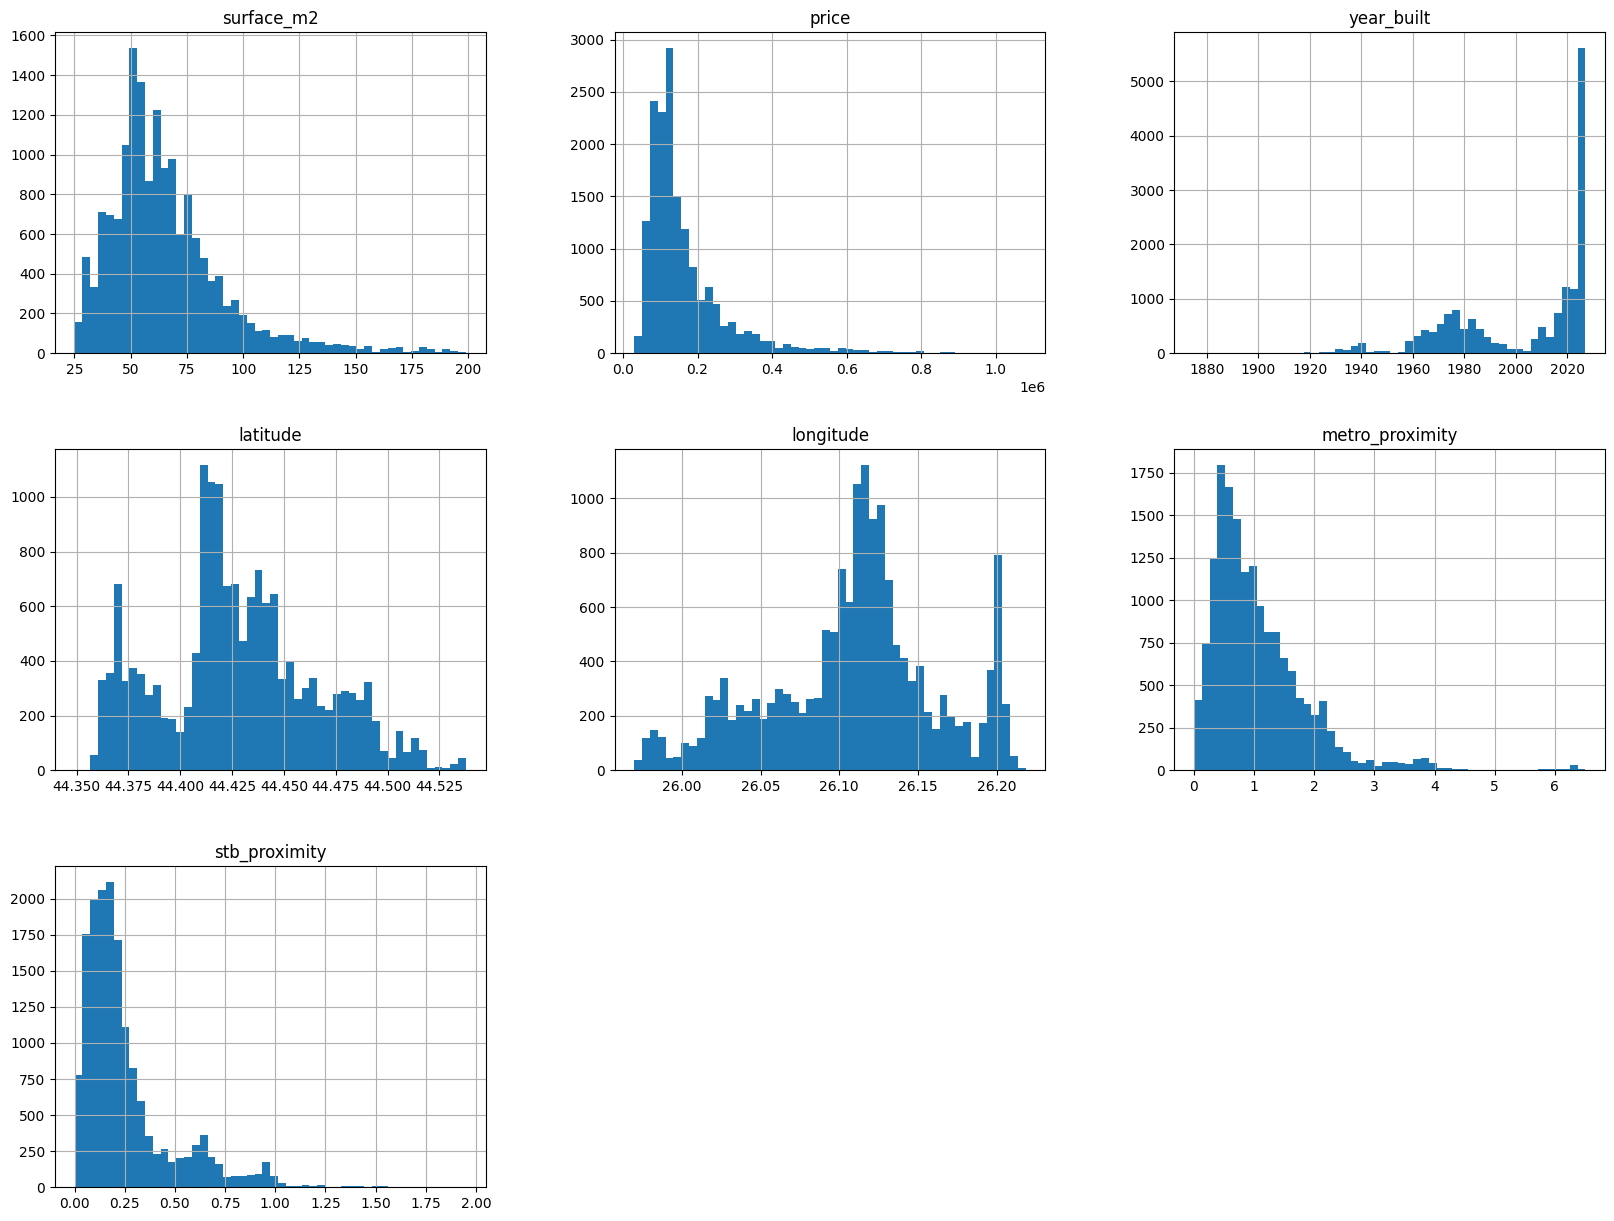

In [5]:
df.hist(figsize=(20,15),bins=50,column=["surface_m2","price","year_built","latitude","longitude","metro_proximity","stb_proximity"])

# Scatter matrix
#### The surface in particular appears to be the only reliable predictor for the price
#### We can also observe that a very high price implies that the unit has been built recently
#### We can also observe that a very high price implies that the unit has been built near the metro station

array([[<Axes: xlabel='price', ylabel='price'>,
        <Axes: xlabel='surface_m2', ylabel='price'>,
        <Axes: xlabel='rooms', ylabel='price'>,
        <Axes: xlabel='metro_proximity', ylabel='price'>,
        <Axes: xlabel='year_built', ylabel='price'>,
        <Axes: xlabel='floor', ylabel='price'>],
       [<Axes: xlabel='price', ylabel='surface_m2'>,
        <Axes: xlabel='surface_m2', ylabel='surface_m2'>,
        <Axes: xlabel='rooms', ylabel='surface_m2'>,
        <Axes: xlabel='metro_proximity', ylabel='surface_m2'>,
        <Axes: xlabel='year_built', ylabel='surface_m2'>,
        <Axes: xlabel='floor', ylabel='surface_m2'>],
       [<Axes: xlabel='price', ylabel='rooms'>,
        <Axes: xlabel='surface_m2', ylabel='rooms'>,
        <Axes: xlabel='rooms', ylabel='rooms'>,
        <Axes: xlabel='metro_proximity', ylabel='rooms'>,
        <Axes: xlabel='year_built', ylabel='rooms'>,
        <Axes: xlabel='floor', ylabel='rooms'>],
       [<Axes: xlabel='price', ylabel='metr

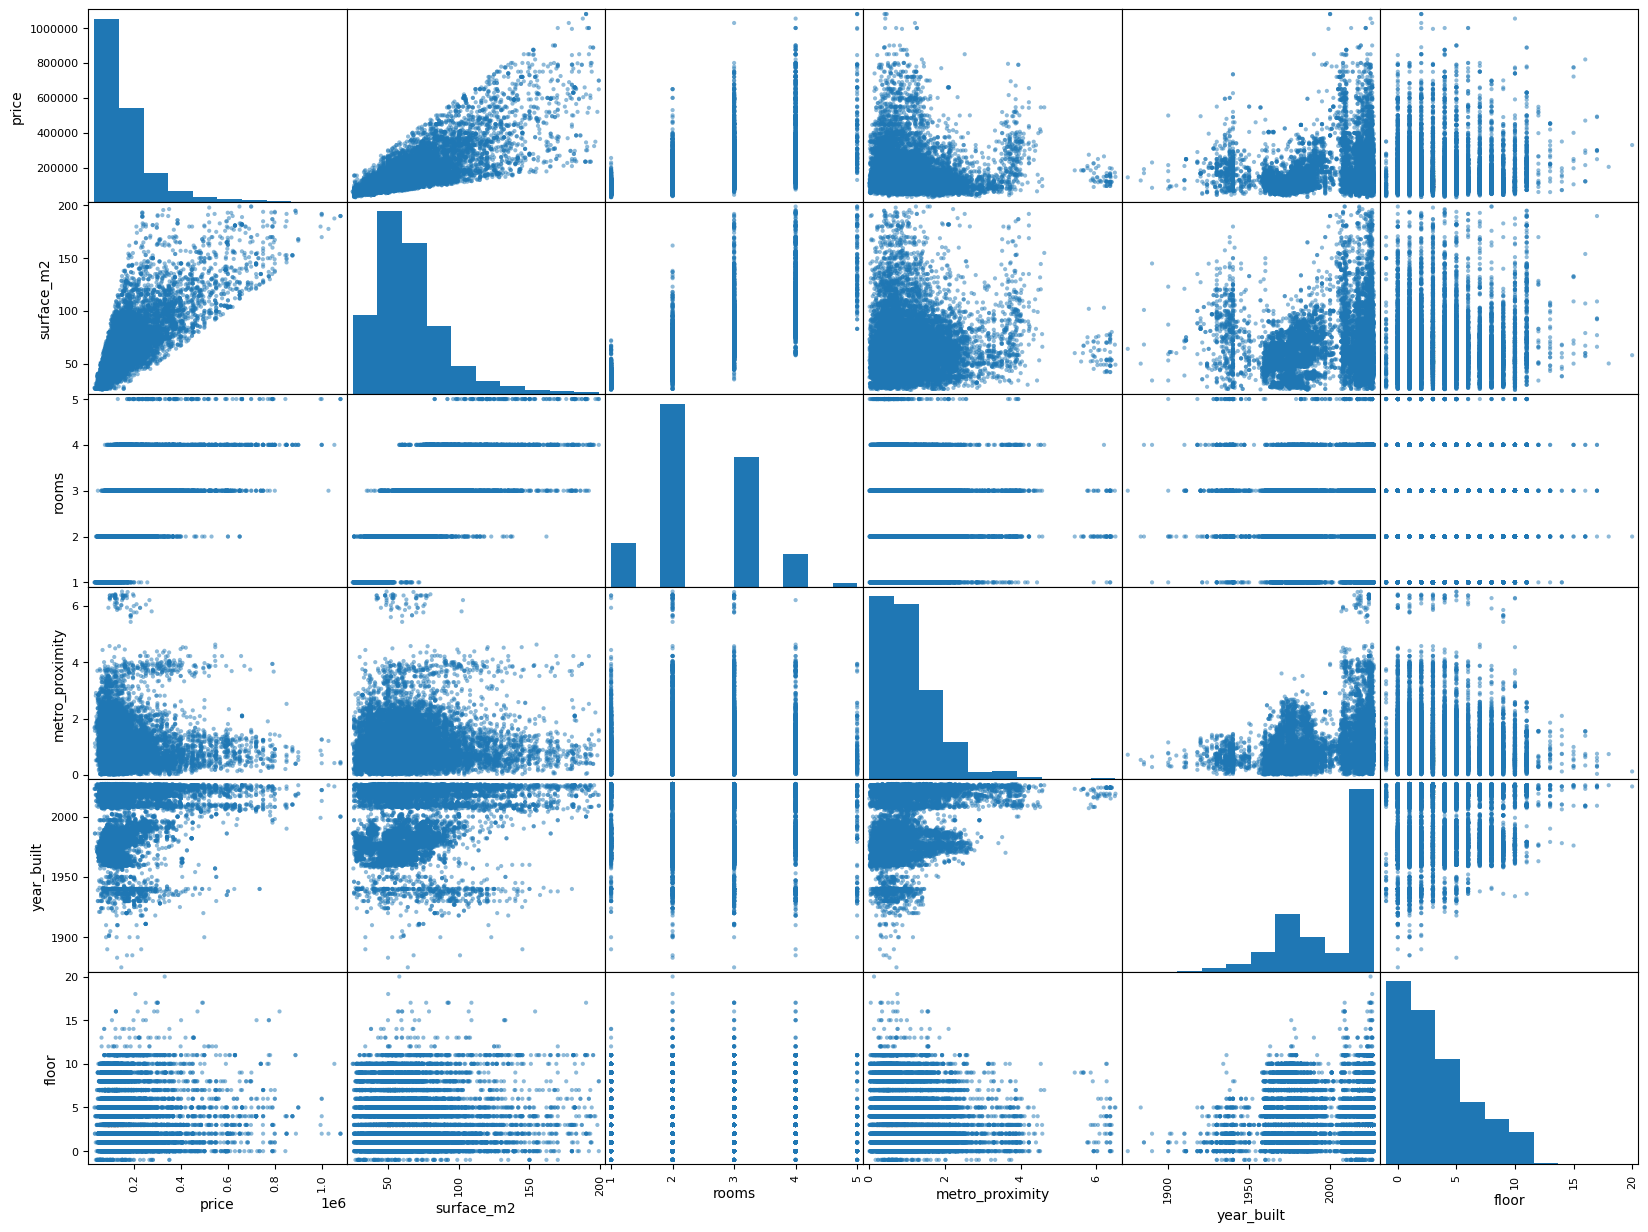

In [6]:
from pandas.plotting import scatter_matrix

attributes = ["price","surface_m2","rooms","metro_proximity","year_built","floor"]

scatter_matrix(df[attributes],figsize=(20,15))

# Correlation matrix
#### There exists a 76% correlation between the price of an appartment and its surface
This confirm the mantra of comparing the price of housing units to how much space they offer. Because of this, in City plot.png, we compare the price of each neighbourhood using price per square meter in order to have a more balanced outlook of each price.
#### There exists a 56% correlation between the price of an appartment and the number of rooms it has
This is in part because the more rooms a unit has, the more space it has to offer. Also more amenities are available if the number of rooms increases.
#### There exists a 32% correlation between the proximity to the subway system and the year it was built
This highlights that real estate developpers love to bulit next to existing transport infrastructure

<Axes: >

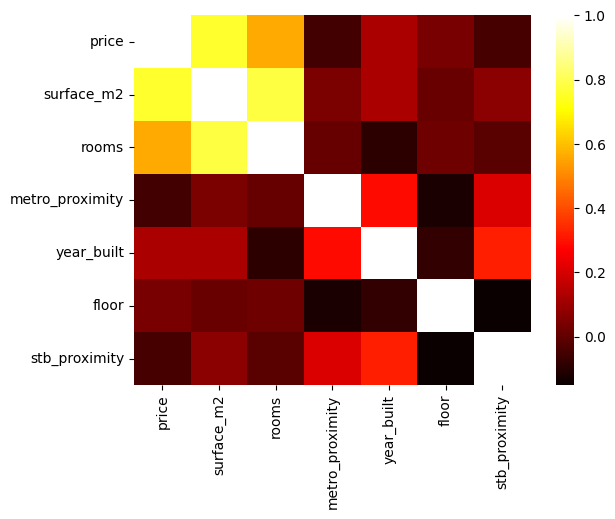

In [7]:
import seaborn as sns
sns.heatmap(df[attributes+["stb_proximity"]].corr(),cmap="hot")

In [8]:
df["price"].corr(df["rooms"])

np.float64(0.5639559044707175)

In [22]:
df["price"].corr(df["surface_m2"])

np.float64(0.7613518066353316)

In [29]:

df["year_built"].corr(df["metro_proximity"].map(lambda x : log(1+x)))

np.float64(0.32041018277660155)

# Data transform
### Applying a log transform to some columns yields a bell curve

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'metro_proximity'}>],
       [<Axes: title={'center': 'surface_m2'}>, <Axes: >]], dtype=object)

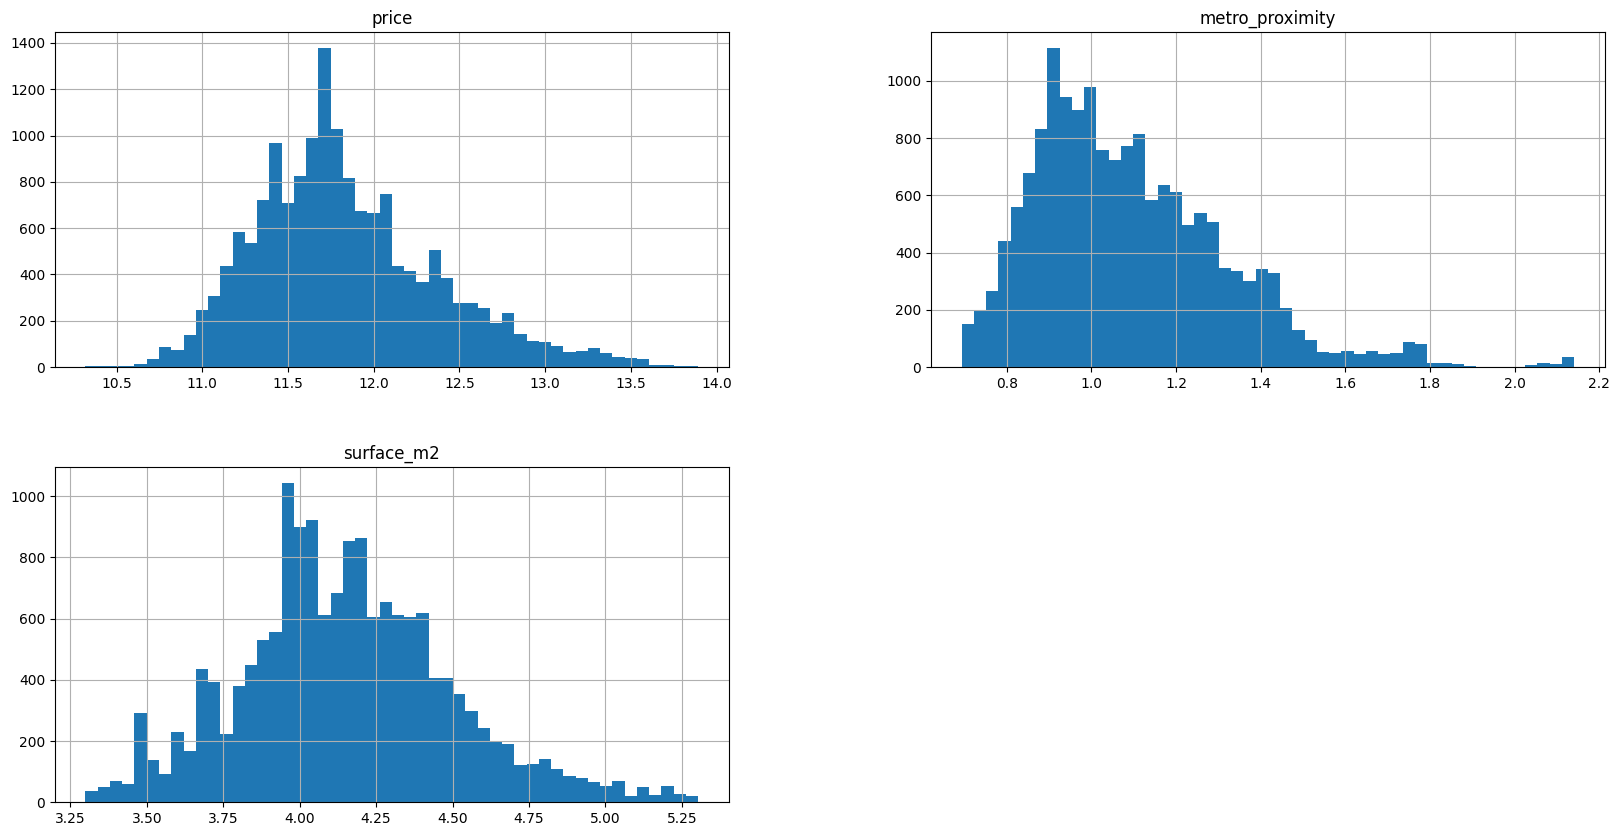

In [ ]:
from numpy import log
df[["price","metro_proximity","surface_m2"]].map(lambda x : log(1+x)).hist(bins = 50,figsize=(20,10))

# Analysis of City plot.png

We can observe 3 zoning trends in the price per square meter:
- Aviatorilor is the only very luxourious neighbourhood
- The city centre also has moderatly expensive housing. It could be considered upper-class
- Outside the broader city centre, the shell of the city is the only area with more affordable housing